## X

Since classification did not end up as simple as anticipated, this notebook will be exploring three models using varying training data. The comparison will be between the OSM-derived data, the newly created Company House data and a mix of both datasets. To more effectively test our data, the FHRS dataset will be manually labelled on a small subset and tested.

In [70]:
from pathlib import Path
from getpass import getpass
from requests.auth import HTTPBasicAuth
import csv

import pandas as pd
import time
import requests


DATA_DATE = "2026-07-28"

RAW_FOLDER= Path("../data/raw")

RAW_FOLDER.mkdir(parents=True, exist_ok=True)

API_URL = ("https://api.company-information.service.gov.uk/advanced-search/companies")


api_key = getpass("Enter Companies House REST API key: ")

session = requests.Session()

session.auth = HTTPBasicAuth(api_key,"")

print("Companies House API session created.")

Companies House API session created.


In [62]:
SIC_CATEGORIES = {
    "47240": {"Description": "Bakery and confectionery retail", "BakeryLabel": 1},
    "47210": {"Description": "Fruit and vegetable retail", "BakeryLabel": 0},
    "47220": {"Description": "Meat retail", "BakeryLabel": 0},
    "47230": {"Description": "Fish retail", "BakeryLabel": 0},
    "47250": {"Description": "Beverage retail", "BakeryLabel": 0},
    "47290": {"Description": "Other specialised food retail", "BakeryLabel": 0},
    "56102": {"Description": "Unlicensed restaurants and cafes", "BakeryLabel": 0},
    "56103": {"Description": "Takeaway food shops and mobile food stands", "BakeryLabel": 0},
}


for sic_code, category in SIC_CATEGORIES.items():
    print(sic_code, category["BakeryLabel"], category["Description"])

47240 1 Bakery and confectionery retail
47210 0 Fruit and vegetable retail
47220 0 Meat retail
47230 0 Fish retail
47250 0 Beverage retail
47290 0 Other specialised food retail
56102 0 Unlicensed restaurants and cafes
56103 0 Takeaway food shops and mobile food stands


In [ ]:
def download_companies_house_dataset(sic_categories, output_path):
    #Parameters from API key Developer Hub
    page_size = 5000
    max_results_per_sic = 10000 #Limited at 10000 per SIC call however this is enough for our classifier

    output_columns = [
        "CompanyNumber",
        "CompanyName",
        "SICCodes",
        "RequestedSIC",
        "BakeryLabel",
    ]

    download_companies_house = {}

    with output_path.open(mode="w", newline="", encoding="utf-8",) as output_file:
        writer = csv.DictWriter(output_file, fieldnames=output_columns)
        writer.writeheader()

        for sic_code, category in sic_categories.items():

            start_index = 0
            total_downloaded = 0

            while True:
                parameters = {
                    "sic_codes": sic_code,
                    "company_status": "active",
                    "size": page_size,
                    "start_index": start_index}

                response = session.get(API_URL, params=parameters, timeout=60)

                response.raise_for_status()

                response_data = response.json()

                companies = response_data.get("items", [],)

                if not companies:
                    break

                for company in companies:
                    writer.writerow({
                        "CompanyNumber": company.get("company_number"),
                        "CompanyName": company.get("company_name"),
                        "SICCodes": "|".join( company.get("sic_codes", [])),
                        "RequestedSIC": sic_code,
                        "BakeryLabel": (category["BakeryLabel"]),
                    })

                page_count = len(companies)

                total_downloaded += page_count
                start_index += page_count

                total_available = int(response_data.get("hits", total_downloaded))
                target_total = min(total_available, max_results_per_sic)

                print(f"SIC {sic_code}: {total_downloaded} of {target_total} from the complete {total_available}")

                if total_downloaded >= target_total:
                    break

            download_companies_house[sic_code] = total_downloaded
        
    print(f"\nRaw Companies House dataset saved to: {output_path}")

    return download_companies_house

In [ ]:
RAW_OUTPUT_PATH = (RAW_FOLDER/f"companies_house_model_data_raw_{DATA_DATE}.csv")

download_companies_house = download_companies_house_dataset(sic_categories=SIC_CATEGORIES, output_path=RAW_OUTPUT_PATH)

print("\nSummary for Companies House raw dataset download:")

for sic_code, company_count in (download_companies_house.items()):
    print(f"{sic_code}: {company_count} rows")

SIC 47240: 5000 of 7888 from the complete 7888
SIC 47240: 7888 of 7888 from the complete 7888
SIC 47210: 4721 of 4721 from the complete 4721
SIC 47220: 5000 of 5845 from the complete 5845
SIC 47220: 5845 of 5845 from the complete 5845
SIC 47230: 1869 of 1869 from the complete 1869
SIC 47250: 5000 of 6018 from the complete 6018
SIC 47250: 6018 of 6018 from the complete 6018
SIC 47290: 5000 of 10000 from the complete 12962
SIC 47290: 10000 of 10000 from the complete 12962
SIC 56102: 5000 of 10000 from the complete 50079
SIC 56102: 10000 of 10000 from the complete 50079
SIC 56103: 5000 of 10000 from the complete 87474
SIC 56103: 10000 of 10000 from the complete 87474

Raw Companies House dataset saved to: ..\data\raw\companies_house_model_raw_2026-07-28.csv

Summary for Companies House raw dataset download:
47240: 7888 rows
47210: 4721 rows
47220: 5845 rows
47230: 1869 rows
47250: 6018 rows
47290: 10000 rows
56102: 10000 rows
56103: 10000 rows


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [73]:
companies_house_raw = pd.read_csv(
    RAW_OUTPUT_PATH,
    dtype={
        "CompanyNumber": "string",
        "CompanyName": "string",
        "SICCodes": "string",
        "RequestedSIC": "string",
    },
)

companies_house_raw["BakeryLabel"] = pd.to_numeric(
    companies_house_raw["BakeryLabel"],
    errors="coerce",
)

companies_house_raw = (
    companies_house_raw
    .dropna(
        subset=[
            "CompanyNumber",
            "CompanyName",
            "BakeryLabel",
        ]
    )
    .copy()
)

companies_house_raw["BakeryLabel"] = (
    companies_house_raw["BakeryLabel"]
    .astype(int)
)

print(
    f"Raw rows: "
    f"{len(companies_house_raw):,}"
)

print("\nRaw label counts:")

print(
    companies_house_raw["BakeryLabel"]
    .value_counts()
    .rename({
        0: "Non-bakery",
        1: "Bakery",
    })
)

companies_house_raw.head()

Raw rows: 56,341

Raw label counts:
BakeryLabel
Non-bakery    48453
Bakery         7888
Name: count, dtype: int64


,CompanyNumber,CompanyName,SICCodes,RequestedSIC,BakeryLabel
0,SC532505,POLIT LTD,47110|47240|47290|47789,47240,1
1,12459244,RAJA TRADING LIMITED,46170|46190|47240,47240,1
2,11691479,SIXTY ONE WALCOT LTD,47240,47240,1
3,10996639,SO SWEET CANDY STORE LIMITED,47240,47240,1
4,12243353,SO SWEET EXETER LIMITED,47240,47240,1


In [74]:
company_label_counts = (
    companies_house_raw
    .groupby("CompanyNumber")["BakeryLabel"]
    .nunique()
)

conflicting_company_numbers = (
    company_label_counts[
        company_label_counts > 1
    ]
    .index
)

print(
    "Companies with conflicting labels:",
    len(conflicting_company_numbers),
)

companies_house_companies = (
    companies_house_raw[
        ~companies_house_raw["CompanyNumber"]
        .isin(conflicting_company_numbers)
    ]
    .drop_duplicates(
        subset="CompanyNumber",
        keep="first",
    )
    .copy()
)

print(
    "Rows after resolving company duplicates:",
    f"{len(companies_house_companies):,}",
)

Companies with conflicting labels: 1432
Rows after resolving company duplicates: 49,591


In [75]:
def clean_business_names(names):
    return (
        names
        .astype("string")
        .str.casefold()
        .str.replace(
            "&",
            " and ",
            regex=False,
        )
        .str.replace(
            "_",
            " ",
            regex=False,
        )
        .str.replace(
            r"[^\w\s]",
            " ",
            regex=True,
        )
        .str.replace(
            r"\s+",
            " ",
            regex=True,
        )
        .str.strip()
    )


companies_house_companies[
    "CleanBusinessName"
] = clean_business_names(
    companies_house_companies[
        "CompanyName"
    ]
)

companies_house_companies[
    "CleanBusinessName"
] = (
    companies_house_companies[
        "CleanBusinessName"
    ]
    .replace(
        "",
        pd.NA,
    )
)

companies_house_companies = (
    companies_house_companies
    .dropna(
        subset="CleanBusinessName",
    )
    .copy()
)

companies_house_companies[
    [
        "CompanyName",
        "CleanBusinessName",
        "BakeryLabel",
    ]
].head()

,CompanyName,CleanBusinessName,BakeryLabel
1,RAJA TRADING LIMITED,raja trading limited,1
2,SIXTY ONE WALCOT LTD,sixty one walcot ltd,1
3,SO SWEET CANDY STORE LIMITED,so sweet candy store limited,1
4,SO SWEET EXETER LIMITED,so sweet exeter limited,1
5,KIDSGROVE PROPERTY LIMITED,kidsgrove property limited,1


In [76]:
name_label_counts = (
    companies_house_companies
    .groupby(
        "CleanBusinessName"
    )["BakeryLabel"]
    .nunique()
)

conflicting_names = (
    name_label_counts[
        name_label_counts > 1
    ]
    .index
)

print(
    "Cleaned names with conflicting labels:",
    len(conflicting_names),
)

companies_house_training = (
    companies_house_companies[
        ~companies_house_companies[
            "CleanBusinessName"
        ].isin(conflicting_names)
    ]
    .drop_duplicates(
        subset="CleanBusinessName",
        keep="first",
    )
    [
        [
            "CompanyName",
            "CleanBusinessName",
            "BakeryLabel",
        ]
    ]
    .rename(
        columns={
            "CompanyName": "DisplayName",
        }
    )
    .reset_index(
        drop=True,
    )
)

print(
    "Unique usable names:",
    f"{len(companies_house_training):,}",
)

print("\nTraining label counts:")

print(
    companies_house_training[
        "BakeryLabel"
    ]
    .value_counts()
    .rename({
        0: "Non-bakery",
        1: "Bakery",
    })
)

companies_house_training.head()

Cleaned names with conflicting labels: 0
Unique usable names: 49,591

Training label counts:
BakeryLabel
Non-bakery    43135
Bakery         6456
Name: count, dtype: int64


,DisplayName,CleanBusinessName,BakeryLabel
0,RAJA TRADING LIMITED,raja trading limited,1
1,SIXTY ONE WALCOT LTD,sixty one walcot ltd,1
2,SO SWEET CANDY STORE LIMITED,so sweet candy store limited,1
3,SO SWEET EXETER LIMITED,so sweet exeter limited,1
4,KIDSGROVE PROPERTY LIMITED,kidsgrove property limited,1


In [77]:
INTERIM_FOLDER = Path(
    "../data/interim"
)

INTERIM_FOLDER.mkdir(
    parents=True,
    exist_ok=True,
)

COMPANIES_HOUSE_TRAINING_PATH = (
    INTERIM_FOLDER
    / (
        "companies_house_training_names_"
        f"{DATA_DATE}.csv"
    )
)

companies_house_training.to_csv(
    COMPANIES_HOUSE_TRAINING_PATH,
    index=False,
)

print(
    "Prepared Companies House training "
    f"data saved to:\n"
    f"{COMPANIES_HOUSE_TRAINING_PATH}"
)

Prepared Companies House training data saved to:
..\data\interim\companies_house_training_names_2026-07-28.csv


In [78]:
companies_house_model_data = (
    companies_house_training[
        [
            "DisplayName",
            "CleanBusinessName",
            "BakeryLabel",
        ]
    ]
    .dropna(
        subset=[
            "CleanBusinessName",
            "BakeryLabel",
        ]
    )
    .copy()
)

X = companies_house_model_data[
    "CleanBusinessName"
]

y = companies_house_model_data[
    "BakeryLabel"
]

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y,
    )
)

print(
    f"Training names: "
    f"{len(X_train):,}"
)

print(
    f"Test names: "
    f"{len(X_test):,}"
)

print(
    f"Training bakeries: "
    f"{y_train.sum():,}"
)

print(
    f"Test bakeries: "
    f"{y_test.sum():,}"
)

Training names: 39,672
Test names: 9,919
Training bakeries: 5,165
Test bakeries: 1,291


In [79]:
companies_house_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
        ),
    ),
])

companies_house_model.fit(
    X_train,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'char_wb'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(3, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [80]:
test_predictions = (
    companies_house_model
    .predict(X_test)
)

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Non-bakery",
            "Bakery",
        ],
        digits=3,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

  Non-bakery      0.943     0.898     0.920      8628
      Bakery      0.484     0.637     0.550      1291

    accuracy                          0.864      9919
   macro avg      0.713     0.768     0.735      9919
weighted avg      0.883     0.864     0.872      9919



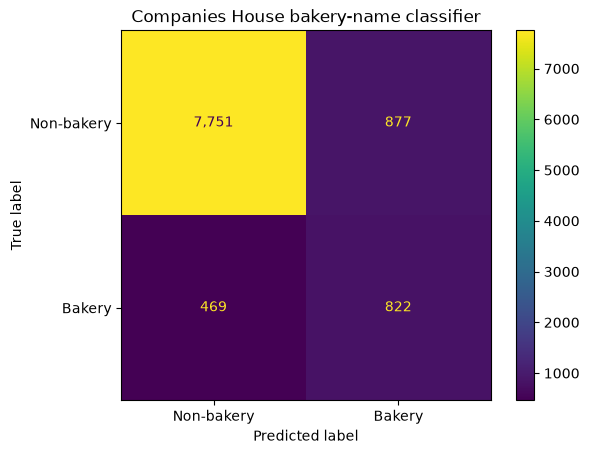

In [81]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=[
        "Non-bakery",
        "Bakery",
    ],
    values_format=",d",
)

plt.title(
    "Companies House bakery-name classifier"
)

plt.show()

In [82]:
bakery_probabilities = (
    companies_house_model
    .predict_proba(X_test)[:, 1]
)

threshold_results = []

for threshold in [
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
]:
    threshold_predictions = (
        bakery_probabilities
        >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        threshold_predictions,
        labels=[0, 1],
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "PredictedBakeries": (
            threshold_predictions.sum()
        ),
        "TruePositives": tp,
        "FalsePositives": fp,
        "FalseNegatives": fn,
        "TrueNegatives": tn,
        "BakeryPrecision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0,
        ),
        "BakeryRecall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0,
        ),
        "BakeryF1": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0,
        ),
    })

companies_house_threshold_comparison = (
    pd.DataFrame(
        threshold_results
    )
    .round(3)
)

companies_house_threshold_comparison

,Threshold,PredictedBakeries,TruePositives,FalsePositives,FalseNegatives,TrueNegatives,BakeryPrecision,BakeryRecall,BakeryF1
0,0.5,1699,822,877,469,7751,0.484,0.637,0.550
1,0.6,1212,734,478,557,8150,0.606,0.569,0.586
2,0.7,916,672,244,619,8384,0.734,0.521,0.609
3,0.8,740,600,140,691,8488,0.811,0.465,0.591
4,0.9,584,494,90,797,8538,0.846,0.383,0.527


In [83]:
osm_default_results = {
    "TrainingSource": "OSM",
    "Threshold": 0.5,
    "BakeryPrecision": 0.422,
    "BakeryRecall": 0.775,
    "BakeryF1": 0.547,
    "TestBakeries": 413,
}

companies_house_default_results = {
    "TrainingSource": "Companies House",
    "Threshold": 0.5,
    "BakeryPrecision": precision_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "BakeryRecall": recall_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "BakeryF1": f1_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "TestBakeries": int(
        y_test.sum()
    ),
}

internal_model_comparison = (
    pd.DataFrame([
        osm_default_results,
        companies_house_default_results,
    ])
    .round(3)
)

internal_model_comparison

,TrainingSource,Threshold,BakeryPrecision,BakeryRecall,BakeryF1,TestBakeries
0,OSM,0.5,0.422,0.775,0.547,413
1,Companies House,0.5,0.484,0.637,0.550,1291


In [84]:
MODEL_FOLDER = Path(
    "../models"
)

MODEL_FOLDER.mkdir(
    parents=True,
    exist_ok=True,
)

COMPANIES_HOUSE_MODEL_PATH = (
    MODEL_FOLDER
    / (
        "companies_house_bakery_name_"
        "classifier.joblib"
    )
)

final_companies_house_model = clone(
    companies_house_model
)

final_companies_house_model.fit(
    X,
    y,
)

joblib.dump(
    final_companies_house_model,
    COMPANIES_HOUSE_MODEL_PATH,
)

print(
    "Companies House model saved to:"
)

print(
    COMPANIES_HOUSE_MODEL_PATH
)

Companies House model saved to:
..\models\companies_house_bakery_name_classifier.joblib
